In [122]:
#import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from xgboost import XGBClassifier
import pandas as pd


In [123]:
#Load Dataset
data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
X = X[[
    'worst concave points',
    'mean concave points',
    'worst area',
    'worst perimeter',
    'concavity error',
    'worst radius'
]]
y=data.target

In [124]:
#split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [125]:
#Train XGboost

model=XGBClassifier(scale_pos_weight=2)
model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [126]:
#Predict
y_pred=model.predict(X_test)

In [127]:
#Evaluate
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [128]:
#Get top features
import pandas as pd

importance = model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

print(feat_imp.sort_values(by="importance", ascending=False).head(10))

                feature  importance
3       worst perimeter    0.344718
0  worst concave points    0.343847
2            worst area    0.118743
1   mean concave points    0.104065
5          worst radius    0.056737
4       concavity error    0.031889


In [129]:
#Feature importance
import matplotlib.pyplot as plt 
from xgboost import plot_importance

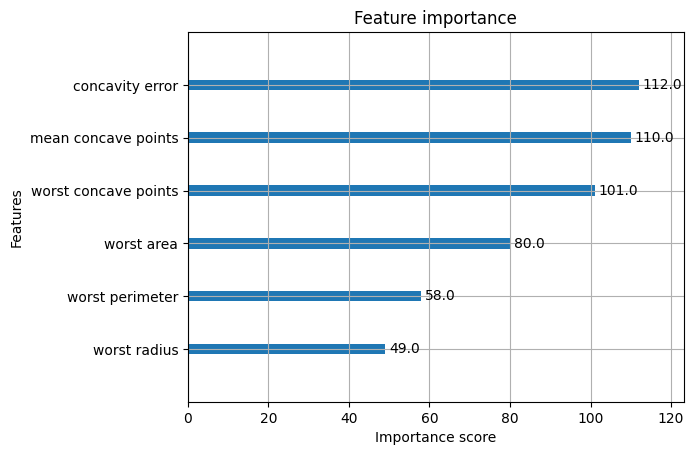

In [130]:
#Plot importance
plot_importance(model)
plt.show()

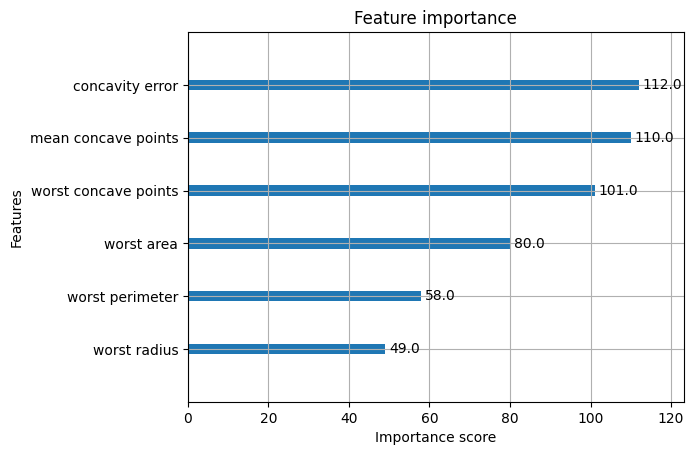

In [131]:
plot_importance(model,importance_type='weight')
plt.show()
plt.show()

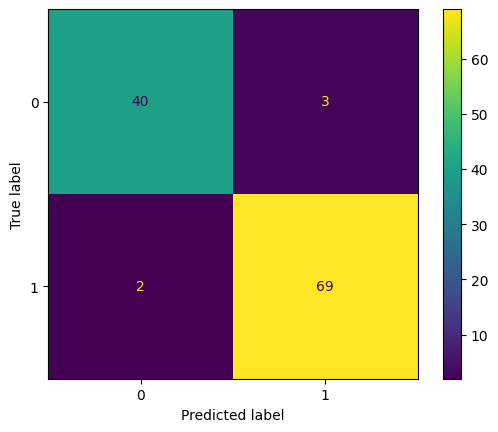

In [132]:
#confusion matrix

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [133]:
y_prob = model.predict_proba(X_test)[:,1]

In [134]:
# Step 1: get probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Step 2: apply threshold
threshold = 0.2
y_pred_new = (y_prob > threshold).astype(int)

# Step 3: evaluate
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[40  3]
 [ 2 69]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



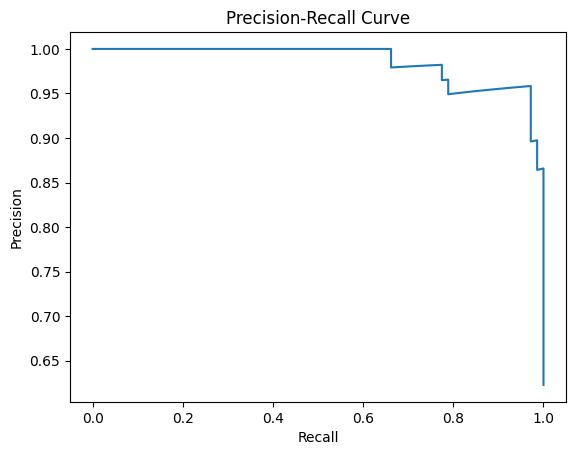

In [135]:
#PR Curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Step 1: get probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Step 2: calculate precision & recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Step 3: plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [136]:
#Print the best threshold
for i in range(len(thresholds)):
    print(f"Threshold: {thresholds[i]:.2f}, Precision: {precision[i]:.2f}, Recall: {recall[i]:.2f}")

Threshold: 0.00, Precision: 0.62, Recall: 1.00
Threshold: 0.00, Precision: 0.63, Recall: 1.00
Threshold: 0.00, Precision: 0.64, Recall: 1.00
Threshold: 0.00, Precision: 0.67, Recall: 1.00
Threshold: 0.00, Precision: 0.68, Recall: 1.00
Threshold: 0.00, Precision: 0.68, Recall: 1.00
Threshold: 0.00, Precision: 0.73, Recall: 1.00
Threshold: 0.00, Precision: 0.74, Recall: 1.00
Threshold: 0.00, Precision: 0.75, Recall: 1.00
Threshold: 0.00, Precision: 0.76, Recall: 1.00
Threshold: 0.00, Precision: 0.77, Recall: 1.00
Threshold: 0.00, Precision: 0.81, Recall: 1.00
Threshold: 0.00, Precision: 0.82, Recall: 1.00
Threshold: 0.00, Precision: 0.83, Recall: 1.00
Threshold: 0.00, Precision: 0.84, Recall: 1.00
Threshold: 0.00, Precision: 0.85, Recall: 1.00
Threshold: 0.00, Precision: 0.86, Recall: 1.00
Threshold: 0.01, Precision: 0.87, Recall: 1.00
Threshold: 0.01, Precision: 0.86, Recall: 0.99
Threshold: 0.01, Precision: 0.88, Recall: 0.99
Threshold: 0.01, Precision: 0.89, Recall: 0.99
Threshold: 0.

C:\Users\14162\AppData\Local\Temp\ipykernel_14700\3534154247.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


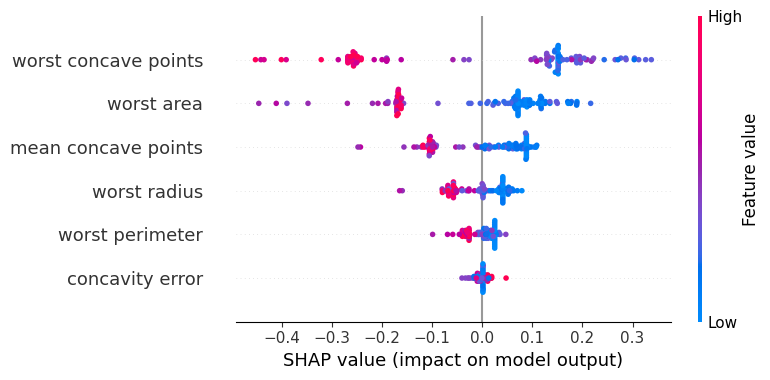

In [137]:
import shap

explainer = shap.Explainer(model.predict, X_train)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

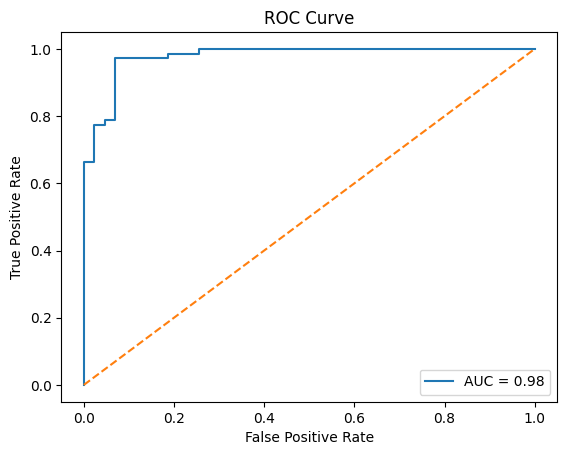

In [138]:
#Roc curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: get probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Step 2: calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Step 3: calculate AUC
roc_auc = auc(fpr, tpr)

# Step 4: plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [139]:
import joblib
joblib.dump(model, "breast_model.pkl")

['breast_model.pkl']

In [140]:
import numpy as np
import streamlit as st
import joblib
from sklearn.datasets import load_breast_cancer

# Load model
model = joblib.load("breast_model.pkl")

# Load dataset to get feature names
data = load_breast_cancer()
feature_names = data.feature_names

st.title("Breast Cancer Prediction App")

st.write("Enter feature values:")

# Store inputs
input_values = []

# Create input fields dynamically
for feature in feature_names:
    value = st.number_input(feature, value=0.0)
    input_values.append(value)

# Predict button
if st.button("Predict"):
    
    input_data = np.array([input_values])
    
    prediction = model.predict(input_data)
    
    if prediction[0] == 1:
        st.error("Malignant ⚠️")
    else:
        st.success("Benign ✅")

2026-03-30 11:06:37.460 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:06:37.462 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:06:37.462 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:06:37.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:06:37.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:06:37.464 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:06:37.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:06:37.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [141]:
import joblib
joblib.dump(model, "breast_model.pkl")

['breast_model.pkl']